In [27]:
# import all the necessary libraries
import pysindy as ps
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

In [28]:
# The van der pol oscillator system
def simple_harmonic_oscillator(t, x, zeta=0.1, omega_n = 1.6, Fhat=0.4, omega=1.4):
    return [x[1], 
           -2*zeta*omega_n*x[1] - omega_n ** 2 * x[0] + Fhat * np.sin(x[2]),
           omega]

In [29]:
# generate the data for testing
start = 0
end = 100
step = 0.01
t_span = [start, end]
x0 = [0.3, 0.1, 0]
sol = solve_ivp(simple_harmonic_oscillator, t_span, x0, dense_output=True)
t = np.arange(start, end+step/10, step)
x = sol.sol(t).T

In [30]:
# The feature names of the columns of y
feature_names = ['x1', 'x2', 'omega t']

# Which feature library to use
poly_lib = ps.PolynomialLibrary(degree=3)
fourier_lib = ps.FourierLibrary()

inputs_temp = np.tile([0, 1, 2], 2)
inputs_per_library = np.reshape(inputs_temp, (2,3))

inputs_per_library[0,2] = 1
inputs_per_library[1,0] = 2
inputs_per_library[1,1] = 2
inputs_per_library[1,2] = 2
print(inputs_per_library)

generalized_library = ps.GeneralizedLibrary(
    [poly_lib, fourier_lib],
inputs_per_library = inputs_per_library)

# Differentiation method
differentiation_method = ps.FiniteDifference(order=2)


# Optimizer
opt = ps.STLSQ(threshold=0.1)
# opt = ps.SR3(threshold=0.1,thresholder="L1")
# opt = ps.FROLS(max_iter=5,alpha=0.5)
# opt = ps.SSR()

# Building the model
model=ps.SINDy(differentiation_method=differentiation_method,
               feature_library = generalized_library,
               feature_names=feature_names, 
              optimizer=opt)


# Fitting the model to the training data
model.fit(x,t=t)

# Print the model
model.print()

model.get_feature_names()

[[0 1 1]
 [2 2 2]]
(x1)' = 1.000 x2
(x2)' = -2.561 x1 + -0.320 x2 + 0.400 sin(1 omega t)
(omega t)' = 1.400 1


['1',
 'x1',
 'x2',
 'x1^2',
 'x1 x2',
 'x2^2',
 'x1^3',
 'x1^2 x2',
 'x1 x2^2',
 'x2^3',
 'sin(1 omega t)',
 'cos(1 omega t)']

In [31]:
# Simulate the identified system 
sim = model.simulate(x0,t=t)

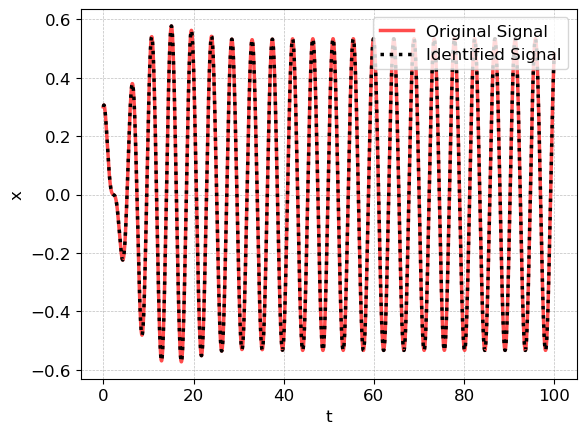

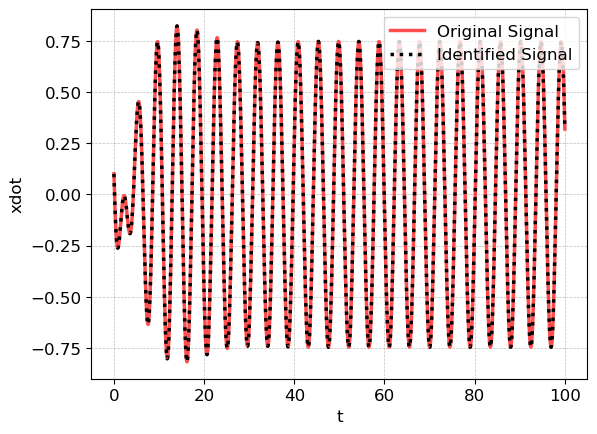

In [32]:
# plot the solution

plt.rcParams.update({'font.size': 12})

# displacement
plt.plot(t,x[:,0],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,0],'k:',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("x")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('disp_sho_f.pdf', format='pdf', dpi=300)
plt.show()


# velocity
plt.plot(t,x[:,1],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,1],'k:',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("xdot")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('vel_sho_f.pdf', format='pdf', dpi=300)
plt.show()

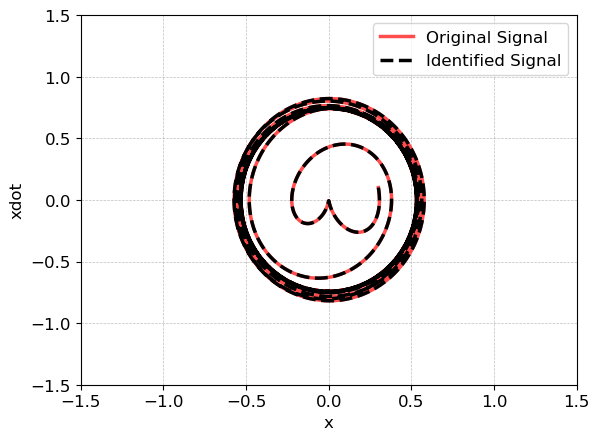

In [36]:
# Phase Portrait
plt.plot(x[:,0],x[:,1],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(sim[:,0],sim[:,1],'k--',linewidth=2.5,label="Identified Signal")
plt.xlabel("x")
plt.ylabel("xdot")
plt.xlim((-1.5,1.5))
plt.ylim((-1.5,1.5))
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('pp_sho_f.pdf', format='pdf', dpi=300)
plt.show()

In [37]:
R2 = r2_score(x[:,0],sim[:,0])
MSE = mean_squared_error(x[:,0],sim[:,0])

print(f"R2 score: {R2}")
print(f"Mean Squared Error: {MSE}")

R2 score: 0.9999997490843985
Mean Squared Error: 3.4002461025634076e-08
